## Load Dataset

In [35]:
import pandas as pd
df=pd.read_csv('survey.csv')
df=pd.DataFrame(df)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

## Preprocessing

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cols = [
    'mental_health_consequence', 'self_employed', 'care_options', 
    'seek_help', 'treatment', 'family_history', 'work_interfere'
]

df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])
df['work_interfere'] = df['work_interfere'].fillna(df['work_interfere'].mode()[0])

for col in cols:
    df[col] = le.fit_transform(df[col])

In [6]:
df['Gender'] = df['Gender'].str.lower().str.strip()

male_terms = [
    'male', 'm', 'male-ish', 'maile', 'cis male', 'mal', 'male (cis)', 
    'make', 'guy (-ish) ^_^', 'man', 'msle', 'mail', 'malr', 'cis man'
]

female_terms = [
    'female', 'f', 'woman', 'femake', 'femail', 'cis female', 
    'cis-female/femme', 'female (cis)', 'female '
]

def group_gender(gender):
    if gender in male_terms:
        return 'male'
    elif gender in female_terms:
        return 'female'
    else:
        return 'other'

df['Gender'] = df['Gender'].apply(group_gender)

df.drop(columns=['Timestamp', 'comments', 'state', 'Country'], inplace=True, errors='ignore')

df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]
print(df['Age'].unique())

[37 44 32 31 33 35 39 42 23 29 36 27 46 41 34 30 40 38 50 24 18 28 26 22
 19 25 45 21 43 56 60 54 55 48 20 57 58 47 62 51 65 49 53 61 72]


## EDA

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1251 entries, 0 to 1258
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        1251 non-null   int64 
 1   Gender                     1251 non-null   object
 2   self_employed              1251 non-null   int64 
 3   family_history             1251 non-null   int64 
 4   treatment                  1251 non-null   int64 
 5   work_interfere             1251 non-null   int64 
 6   no_employees               1251 non-null   object
 7   remote_work                1251 non-null   object
 8   tech_company               1251 non-null   object
 9   benefits                   1251 non-null   object
 10  care_options               1251 non-null   int64 
 11  wellness_program           1251 non-null   object
 12  seek_help                  1251 non-null   int64 
 13  anonymity                  1251 non-null   object
 14  leave        

In [8]:
for i in df.columns:
    if i=="comments":
        pass
    else:
        print(f"\n{i}",df[i].unique())


Age [37 44 32 31 33 35 39 42 23 29 36 27 46 41 34 30 40 38 50 24 18 28 26 22
 19 25 45 21 43 56 60 54 55 48 20 57 58 47 62 51 65 49 53 61 72]

Gender ['female' 'male' 'other']

self_employed [0 1]

family_history [0 1]

treatment [1 0]

work_interfere [1 2 0 3]

no_employees ['6-25' 'More than 1000' '26-100' '100-500' '1-5' '500-1000']

remote_work ['No' 'Yes']

tech_company ['Yes' 'No']

benefits ['Yes' "Don't know" 'No']

care_options [1 0 2]

wellness_program ['No' "Don't know" 'Yes']

seek_help [2 0 1]

anonymity ['Yes' "Don't know" 'No']

leave ['Somewhat easy' "Don't know" 'Somewhat difficult' 'Very difficult'
 'Very easy']

mental_health_consequence [1 0 2]

phys_health_consequence ['No' 'Yes' 'Maybe']

coworkers ['Some of them' 'No' 'Yes']

supervisor ['Yes' 'No' 'Some of them']

mental_health_interview ['No' 'Yes' 'Maybe']

phys_health_interview ['Maybe' 'No' 'Yes']

mental_vs_physical ['Yes' "Don't know" 'No']

obs_consequence ['No' 'Yes']


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

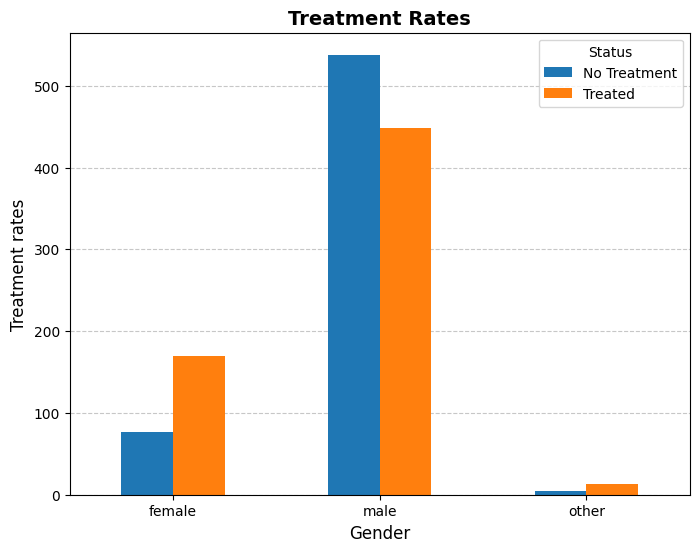

In [10]:
treatment_rates=df.groupby('Gender')['treatment'].value_counts()

ax=treatment_rates.unstack().plot(kind='bar', figsize=(8, 6))
ax.set_axisbelow(True)

plt.title('Treatment Rates', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Treatment rates', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status', labels=['No Treatment', 'Treated'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

mental_vs_physical  Don't know  No  Yes
no_employees                           
1-5                         57  38   63
6-25                       139  62   88
26-100                     143  83   62
100-500                     85  53   37
500-1000                    28  14   18
More than 1000             122  88   71


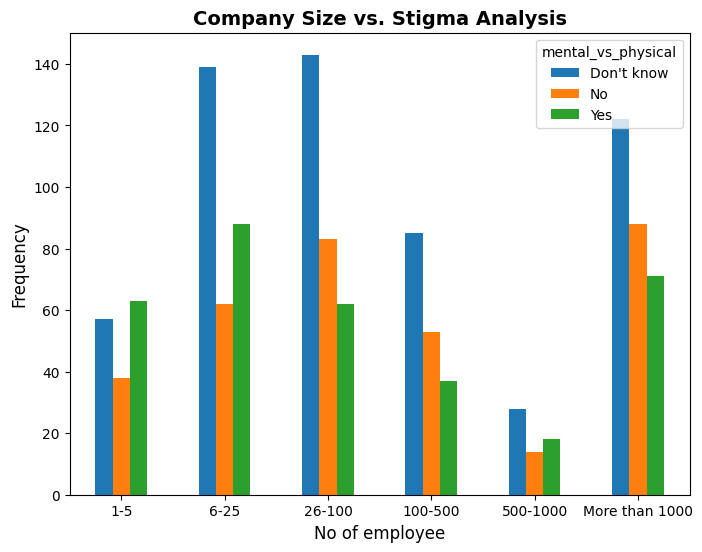

In [11]:
size_order = ['1-5', '6-25', '26-100','100-500','500-1000','More than 1000']
df['no_employees'] = pd.Categorical(df['no_employees'], categories=size_order, ordered=False)

health=df.groupby('no_employees',observed=True)['mental_vs_physical'].value_counts()
print(health.unstack())

ax=health.unstack().plot(kind='bar', figsize=(8, 6))
ax.set_axisbelow(True)

# plt.hist(df['mental_vs_physical'], bins=30, density=True, alpha=0.6, color='b', edgecolor='black')
plt.title('Company Size vs. Stigma Analysis', fontsize=14, fontweight='bold')
plt.xlabel('No of employee', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=0)
plt.show()

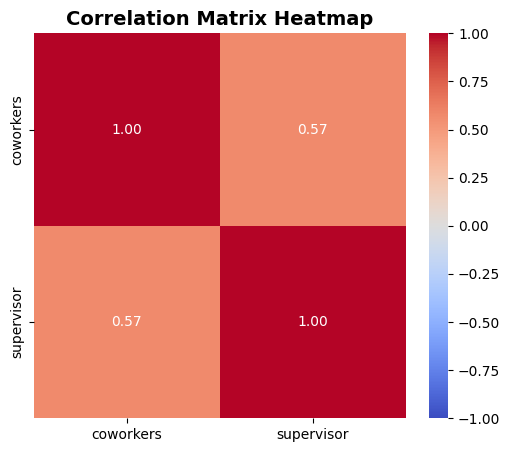

In [12]:
le = LabelEncoder()

df['coworkers'] = le.fit_transform(df['coworkers'])
df['supervisor'] = le.fit_transform(df['supervisor'])

# ct = pd.crosstab(df['coworkers'], df['supervisor'])
# print(ct)
corr_matrix = df[['coworkers', 'supervisor']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.show()

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


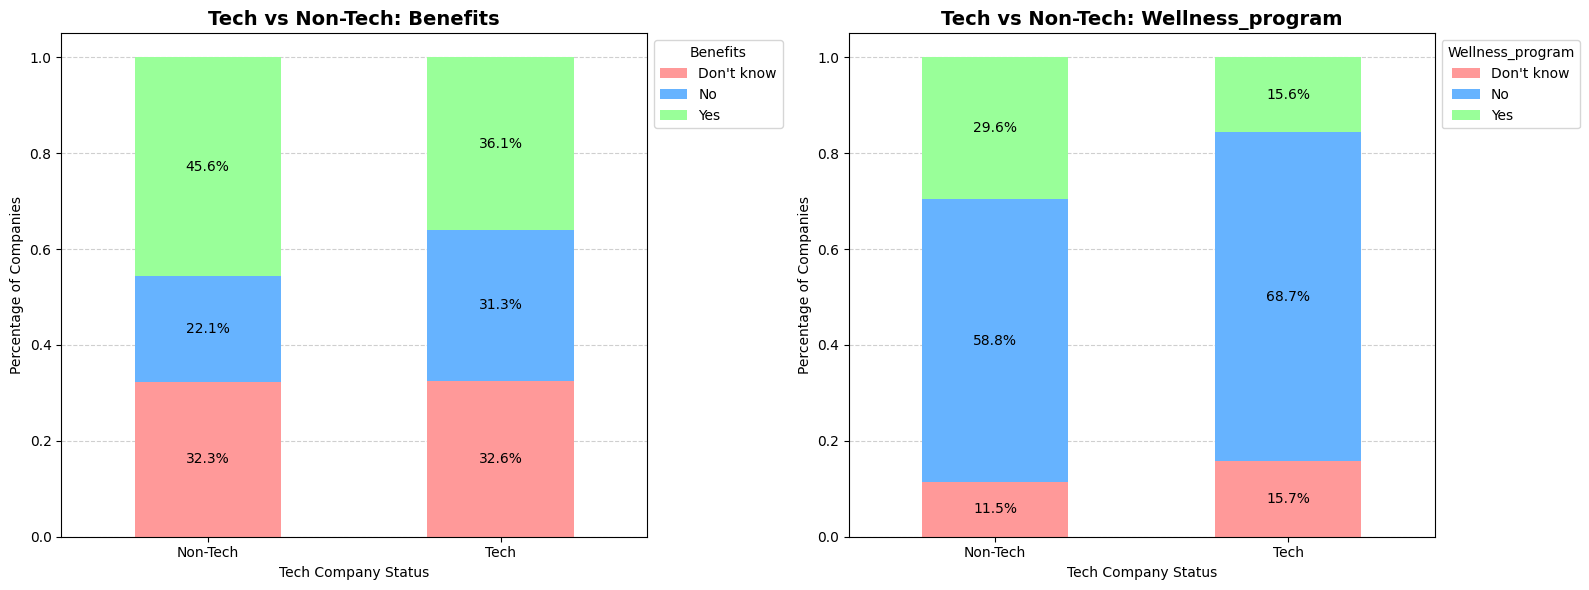

In [13]:
support_features = ['benefits', 'wellness_program']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(support_features):
    analysis = pd.crosstab(df['tech_company'], df[col], normalize='index')
    
    analysis.plot(kind='bar', stacked=True, ax=axes[i], color=['#ff9999','#66b3ff','#99ff99'])
    # print(axes[i])
    print(ax)
    for p in axes[i].patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy() 
        if height > 0.05: # Only show label if the segment is large enough to read
            axes[i].text(x + width/2, 
                         y + height/2, 
                         f'{height*100:.1f}%', 
                         horizontalalignment='center', 
                         verticalalignment='center',
                         fontsize=10,                         
                         color='black') 

    axes[i].set_title(f'Tech vs Non-Tech: {col.capitalize()}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Percentage of Companies')
    axes[i].set_xlabel('Tech Company Status')
    axes[i].legend(title=col.capitalize(), bbox_to_anchor=(1, 1))
    axes[i].set_xticklabels(['Non-Tech', 'Tech'], rotation=0)
    
    axes[i].set_axisbelow(True)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

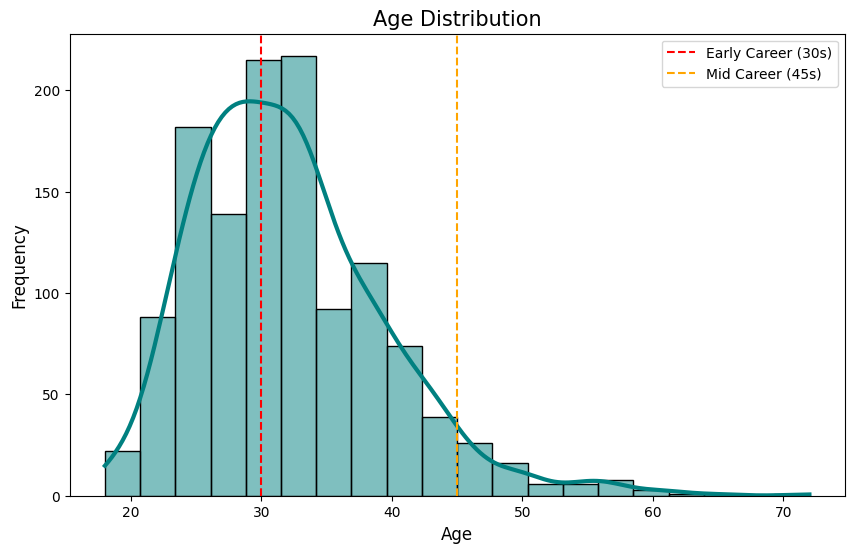

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='teal', bins=20, line_kws={'linewidth': 3})

plt.axvline(30, color='red', linestyle='--', label='Early Career (30s)')
plt.axvline(45, color='orange', linestyle='--', label='Mid Career (45s)')

plt.title('Age Distribution', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.show()

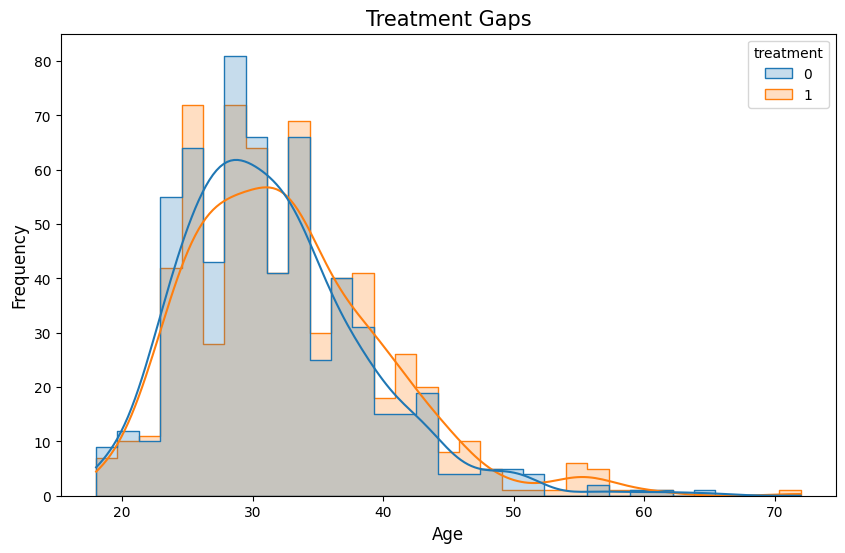

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='treatment',kde=True, element="step")
plt.title('Treatment Gaps', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# plt.legend(title='Treatment',labels=['No treatment','Treated'])
plt.show()

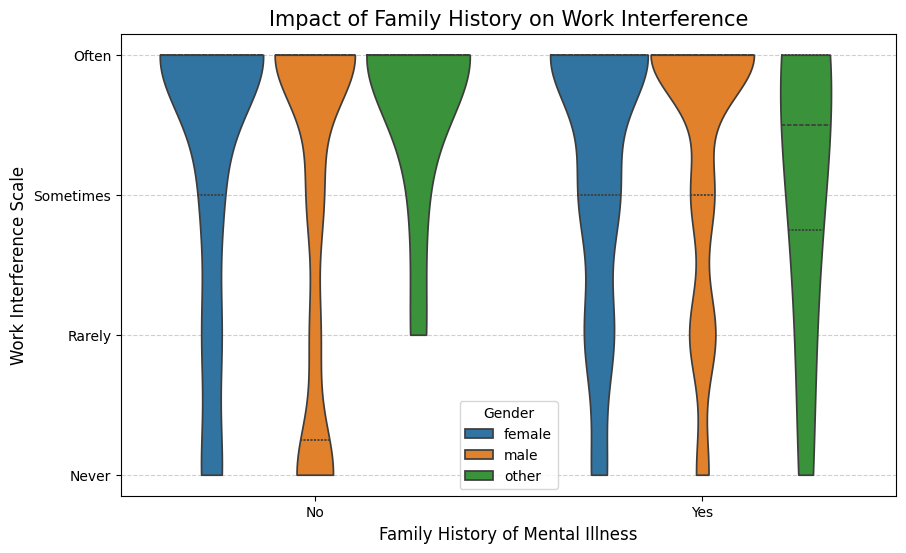

In [16]:
plt.figure(figsize=(10, 6))
ax=sns.violinplot(data=df, x='family_history', y='work_interfere', inner="quartile",hue='Gender', cut=0)
ax.set_axisbelow(True)

plt.title('Impact of Family History on Work Interference', fontsize=15)
plt.xlabel('Family History of Mental Illness', fontsize=12)
plt.ylabel('Work Interference Scale', fontsize=12)
plt.xticks([0, 1], ['No','Yes'])
plt.yticks([0, 1, 2, 3], ['Never', 'Rarely', 'Sometimes', 'Often'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

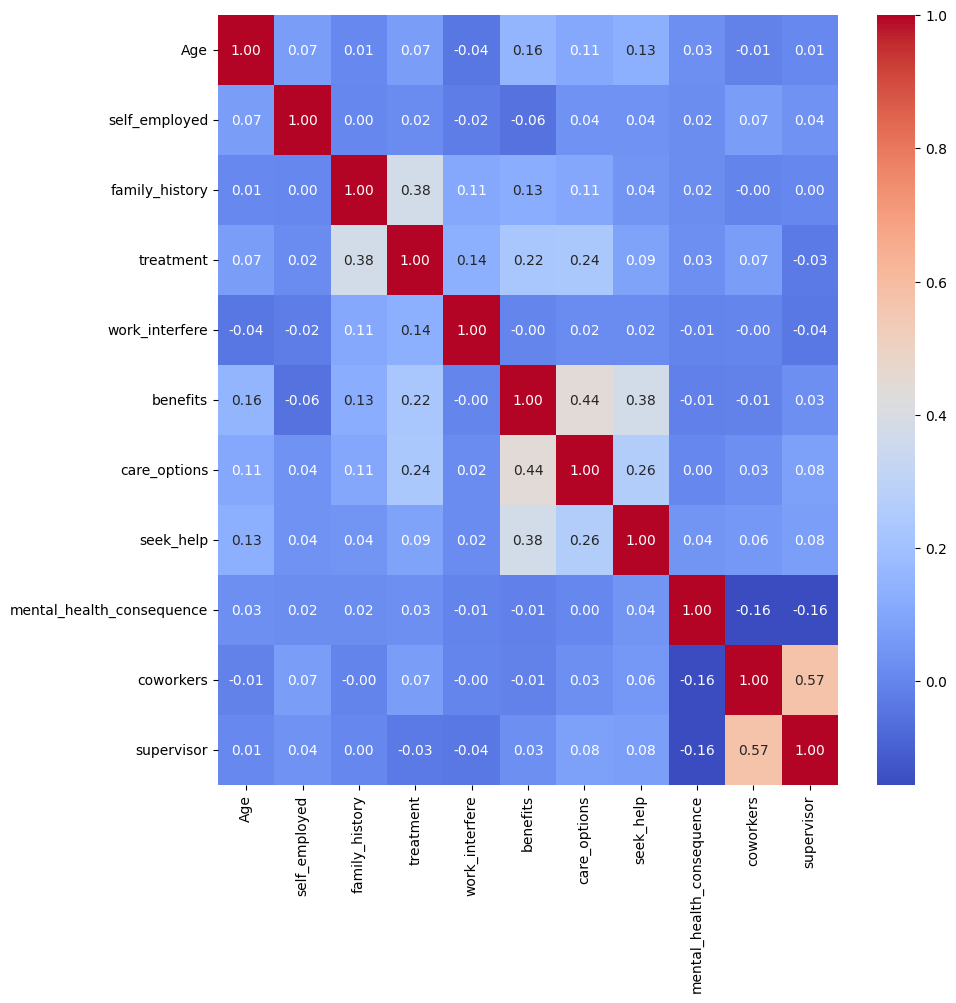

In [17]:
df['benefits']=le.fit_transform(df['benefits'])
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## Regression Models

In [18]:
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

X=df[['work_interfere','Age','self_employed','care_options','seek_help','family_history','benefits']]
y=df['treatment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43)


#### Linear Regression


In [19]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_pred = lin_model.predict(X_test)

print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, lin_pred):.4f}")
print(f"R-squared: {r2_score(y_test, lin_pred):.4f}")

Mean Squared Error (MSE): 0.1987
R-squared: 0.2054


#### Decision Tree Regression

In [20]:
from sklearn.tree import DecisionTreeRegressor

dt_reg = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_reg.fit(X_train, y_train)

reg_pred = dt_reg.predict(X_test)
print(f"Regressor R-squared: {r2_score(y_test, reg_pred):.4f}")

Regressor R-squared: 0.2559


#### KNN Regression

In [21]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)

reg_pred = knn_reg.predict(X_test)
print(f"KNN Regressor R-squared: {r2_score(y_test, reg_pred):.4f}")

KNN Regressor R-squared: 0.1026


## Classification Models

#### LogisticRegression

In [22]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, log_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, log_pred))

Accuracy Score: 0.7234

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.75      0.73       188
           1       0.74      0.70      0.72       188

    accuracy                           0.72       376
   macro avg       0.72      0.72      0.72       376
weighted avg       0.72      0.72      0.72       376



#### Decision Tree Classification

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_clf.fit(X_train, y_train)

clf_pred = dt_clf.predict(X_test)
print(f"Classifier Accuracy: {accuracy_score(y_test, clf_pred):.4f}")

Classifier Accuracy: 0.7606


In [24]:
dt_clf_optimized = DecisionTreeClassifier(
    max_depth=6,              # Increased from 4
    min_samples_split=10,     # Minimum samples to split a node
    min_samples_leaf=10,      # Minimum samples in leaf node
    max_features='sqrt',      # Number of features to consider
    criterion='gini',         # Split criterion
    class_weight='balanced',  # Handle class imbalance
    random_state=40
)

dt_clf_optimized.fit(X_train, y_train)
dt_pred_optimized = dt_clf_optimized.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, dt_pred_optimized):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred_optimized))

Accuracy Score: 0.7500

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.78      0.76       188
           1       0.77      0.72      0.74       188

    accuracy                           0.75       376
   macro avg       0.75      0.75      0.75       376
weighted avg       0.75      0.75      0.75       376



#### KNN Classification

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)

clf_pred = knn_clf.predict(X_test)
print(f"KNN Classifier Accuracy: {accuracy_score(y_test, clf_pred):.4f}")

KNN Classifier Accuracy: 0.6835


#### Random Forest Classification

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random forest classification: ",accuracy_score(y_test, rf_pred))

Random forest classification:  0.7021276595744681


In [27]:
rf_atf = RandomForestClassifier(

    n_estimators   = 300,          # 279-384
        max_depth      = 12,        # ← KEY FIX: was None (unlimited)
        min_samples_split = 10,    # ← KEY FIX: was 2
        min_samples_leaf  = 4,     # ← KEY FIX: was 1
        max_features   = 'sqrt',
        class_weight   = 'balanced',
        random_state   = 42,
)
rf_atf.fit(X_train, y_train)

training =rf_atf.predict(X_train)
print("training data's accuracy = ",accuracy_score(y_train,training))

rf_pred = rf_atf.predict(X_test)
print("Random forest classification: ",accuracy_score(y_test, rf_pred))



training data's accuracy =  0.7908571428571428
Random forest classification:  0.7712765957446809


#### XGBoost

In [28]:
from xgboost import XGBClassifier
import xgboost as xgb


model = XGBClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

training =model.predict(X_train)
print("training data's accuracy = ",accuracy_score(y_train,training))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

training data's accuracy =  0.9017142857142857
Accuracy: 68.35%


In [29]:
model = xgb.XGBClassifier(
    n_estimators=123,       # 123-129=0.7633
    learning_rate=0.09,      # 0.09=0.7686
    max_depth=3,            
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

training =model.predict(X_train)
print("training data's accuracy = ",accuracy_score(y_train,training))

accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {accuracy:.4f}")

training data's accuracy =  0.7874285714285715
XGBoost Accuracy: 0.7660


d:\Internship\Streamlit\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:11:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

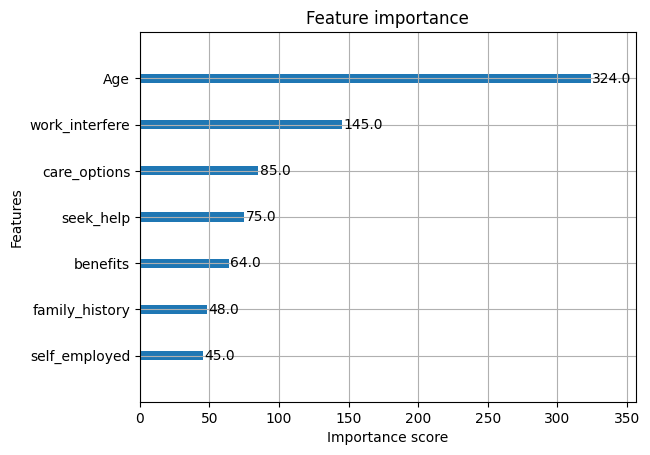

In [30]:
xgb.plot_importance(model)

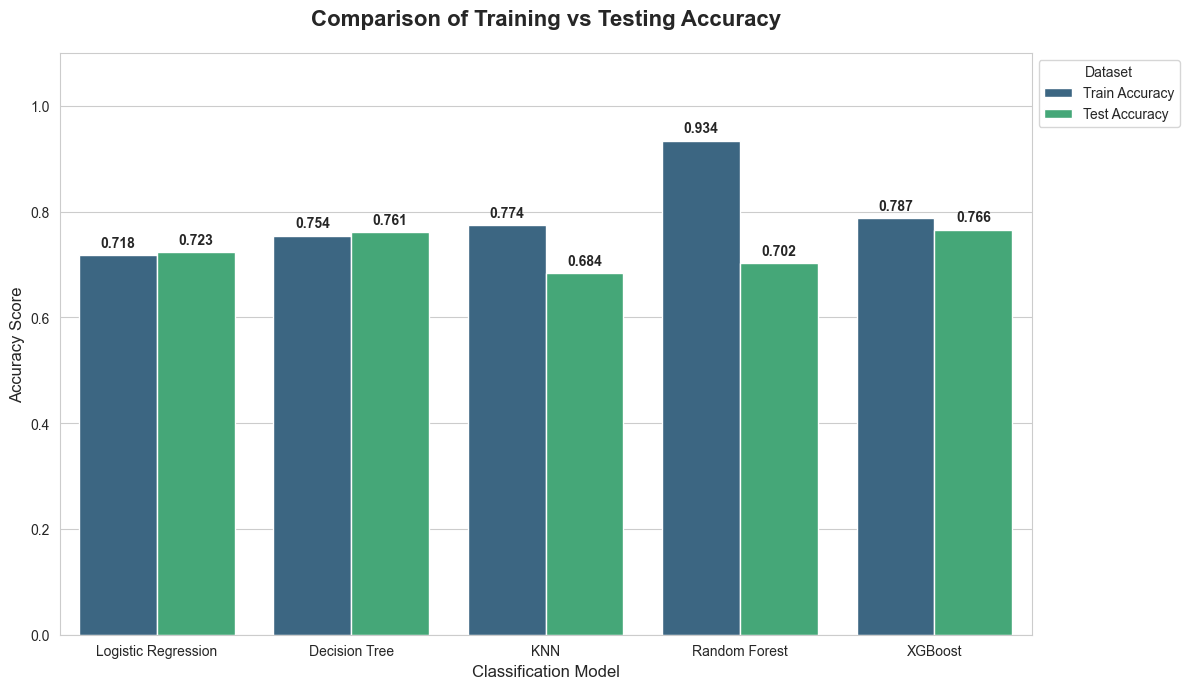

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': log_model,
    'Decision Tree': dt_clf,
    'KNN': knn_clf,
    'Random Forest': rf,
    'XGBoost': model
}

results = []

for name, clf in models.items():
    # Training Accuracy
    train_pred = clf.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    
    # Testing Accuracy
    test_pred = clf.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    
    results.append({'Model': name, 'Type': 'Train Accuracy', 'Score': train_acc})
    results.append({'Model': name, 'Type': 'Test Accuracy', 'Score': test_acc})

# 3. Create a DataFrame
df_results = pd.DataFrame(results)

# 4. Generate the Plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create the grouped bar chart
ax = sns.barplot(x='Model', y='Score', hue='Type', data=df_results, palette='viridis')

# Customizing the graph
plt.title('Comparison of Training vs Testing Accuracy', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Classification Model', fontsize=12)
plt.ylim(0, 1.1)  # Set limit slightly above 1.0 for labels
plt.legend(title='Dataset', loc='upper left', bbox_to_anchor=(1, 1))

# Add the specific values on top of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.3f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

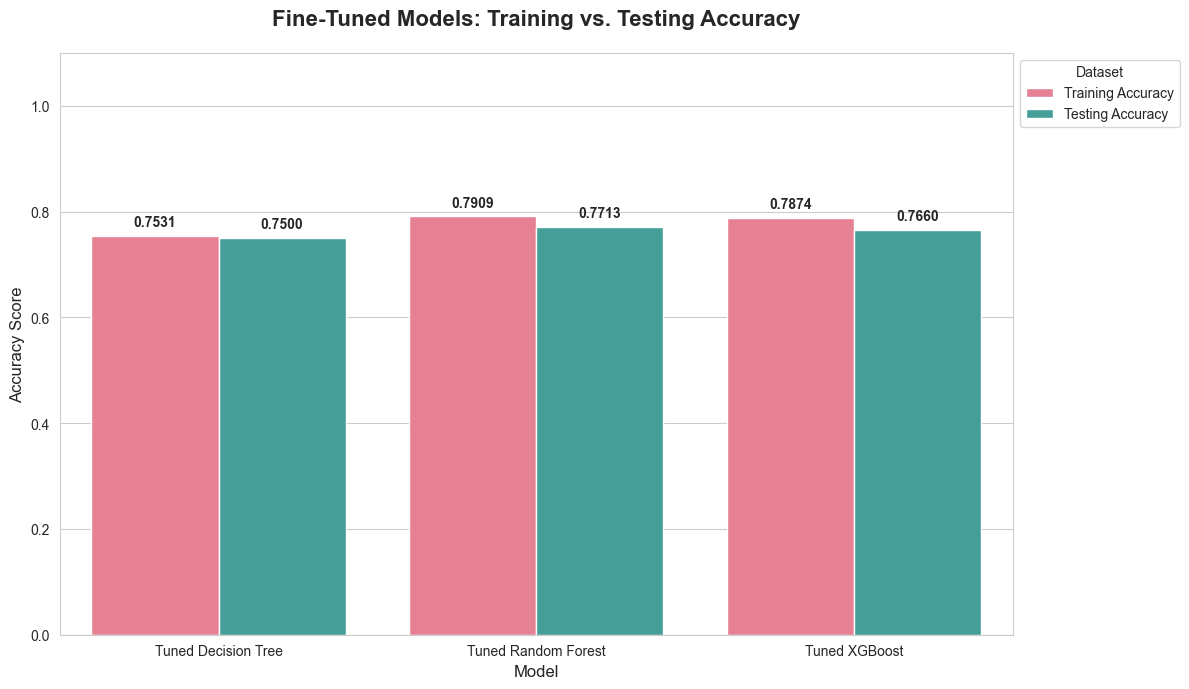

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score

# 1. Define your fine-tuned models
tuned_models = {
    'Tuned Decision Tree': dt_clf_optimized,
    'Tuned Random Forest': rf_atf,
    'Tuned XGBoost': model
}

# 2. Calculate accuracies
comparison_data = []

for name, clf in tuned_models.items():
    # Training Accuracy
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    # Testing Accuracy
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    
    comparison_data.append({'Model': name, 'Type': 'Training Accuracy', 'Score': train_acc})
    comparison_data.append({'Model': name, 'Type': 'Testing Accuracy', 'Score': test_acc})

# 3. Create DataFrame
df_compare = pd.DataFrame(comparison_data)

# 4. Plotting
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create grouped bars
ax = sns.barplot(x='Model', y='Score', hue='Type', data=df_compare, palette='husl')

# Formatting
plt.title('Fine-Tuned Models: Training vs. Testing Accuracy', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 1.1)  # Space for labels
plt.legend(title='Dataset', loc='upper left', bbox_to_anchor=(1, 1))

# Add data labels on top of the bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.4f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [33]:
import joblib
import os

# Create a directory to store models (optional but good practice)
os.makedirs('models', exist_ok=True)

# Save the trained model
joblib.dump(rf_atf, 'models/rf_atf_model.pkl')
print("Model saved successfully!")

# ✅ Verify it loads correctly
loaded_model = joblib.load('models/rf_atf_model.pkl')
test_pred = loaded_model.predict(X_test)
print("Verification accuracy:", accuracy_score(y_test, test_pred))

Model saved successfully!
Verification accuracy: 0.7712765957446809


## SMOTE technique

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Original class counts: {y_train.value_counts().to_dict()}")
print(f"Balanced class counts: {pd.Series(y_train_bal).value_counts().to_dict()}")


Original class counts: {1: 444, 0: 431}
Balanced class counts: {0: 444, 1: 444}

--- Random Forest (SMOTE) ---
Train Accuracy: 0.7872
Test Accuracy:  0.7606

--- XGBoost (SMOTE) ---
Train Accuracy: 0.8964
Test Accuracy:  0.7048
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       188
           1       0.71      0.69      0.70       188

    accuracy                           0.70       376
   macro avg       0.71      0.70      0.70       376
weighted avg       0.71      0.70      0.70       376



In [ ]:

# --- Random Forest with SMOTE ---
rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced', # Combined with SMOTE, this is very strong
    random_state=42
)

rf_smote.fit(X_train_bal, y_train_bal)
rf_pred = rf_smote.predict(X_test)

print("\n--- Random Forest (SMOTE) ---")
print(f"Train Accuracy: {accuracy_score(y_train_bal, rf_smote.predict(X_train_bal)):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
# print(classification_report(y_test, rf_pred)EE

# 3. --- XGBoost with SMOTE ---
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_bal, y_train_bal)
xgb_pred = xgb_model.predict(X_test)

print("\n--- XGBoost (SMOTE) ---")
print(f"Train Accuracy: {accuracy_score(y_train_bal, xgb_model.predict(X_train_bal)):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, xgb_pred):.4f}")
print(classification_report(y_test, xgb_pred))